<div style="font-size: 2em; font-weight: bold; margin-top: 0.67em; margin-bottom: 0.67em;">
UE L2 Projet de Statistique CMI OSIA
</div>

</a>
<div style="font-size: 1em; font-weight: bold; margin-top: 0.67em; margin-bottom: 0.67em;">
Année 2026-2027
</div>
<div style="color: blue; font-size: 1.5em; font-weight: bold; margin-top: 0.67em; margin-bottom: 0.67em;">
Nom : du Reau - Prénom : Baptiste

Nom : Caillot - Prénom : Aïdan
</div>


Modèle de compte-rendu du projet avec codes commentés, sorties numériques et graphiques

<div style="font-size: 1em; font-weight: bold; margin-top: 0.67em; margin-bottom: 0.67em;">
Importation des données
</div>

Le code ci-dessous permet d'importer ces différents fichiers, de visualiser leur contenu ainsi que leur organisation sous forme de DataFrame Pandas.

**Noms et coordonnées des stations**

In [1]:
import pandas as pd

stations_toulouse = pd.read_parquet("stations_toulouse.parquet")

**Données d'entrainement**

``history_toulouse_train`` dans le code ci-dessous est un DataFrame Pandas, avec :
- des lignes identifiées par un MultiIndex (nom de la station et date de mesure)
- des colonnes nommées ``bikes`` et ``stands``qui contiennent respectivement le nombre de vélos disponibles et le nombre de vélos manquants pour une station et une date (jour/heure) données

In [2]:
history_toulouse_train = pd.read_parquet("history_toulouse_train.parquet")

**Données de test**

``history_toulouse_test`` dans le code ci-dessous est un DataFrame Pandas, avec :
- des lignes identifiées par un MultiIndex (une station à la date de la dernière mesure faite dans les données d'entraînement)
- des colonnes nommées ``bikes_+15min``,...,``bikes_+120min`` qui doivent être complétées par des prévisions tous les 15 minutes pendant 2 heures

In [3]:
history_toulouse_test = pd.read_parquet("history_toulouse_test.parquet")

<div style="font-size: 2em; font-weight: bold; margin-top: 0.67em; margin-bottom: 0.67em;">
Statistique descriptive des données
</div>

Vous devez inclure ici les résultats de statistique descriptive qui vous semblent pertinents pour le problème de prévision du nombre de vélos. Vous devez en particulier répondre aux questions suivantes :

- (a) déterminer le nombre maximal de vélos disponibles par station et afficher sur une carte les stations en fonction d'un code couleur proportionnel à ce nombre
- (b) déterminer s'il existe des valeurs manquantes dans les données
- (c) déterminer les nombres de mesures pour chaque station et afficher un histogramme de leur répartition
- (d) déterminer les dates de début et de fin des mesures par stations, et faire une représentation graphique de leur dispersion
- (e) proposer des statistique de base par station : maximimum, minimum, moyenne, écart-type, quartiles, et en faire une représentation par Boxplot
- (f) calculer la courbe moyenne journalière de remplissage d'une station (toutes les 15 minutes), et de l'ensemble des stations / calculer également la courbe médiane, 1er-quartile, 3-ème quartile
- (g) tracer sur quelques cartes l'évolution temporelle de remplissage moyen de l'ensemble des stations en choisissant quelques moments dans une journée et en déduire des dynamiques urbaines de remplissage en fonction des heures de la journée et de la localisation des stations
- (h) autres idées ?...

<div style="font-size: 1em; font-weight: bold; margin-top: 0.67em; margin-bottom: 0.67em;">
(a) Affichage du nombre maximal de vélos disponibles par station
</div>
Création d'une fonction pour afficher des cartes facilement (pas de duplication de code)

In [4]:
import folium
import branca.colormap as cm

def carte_coloree(data, legende, min_1 = None, max_1 = None):
    stations_toulouse["data"] = (
        stations_toulouse["station"].map(data)
    )

    if min_1 == None:
        min_1 = stations_toulouse["data"].min()

    if max_1 == None:
        max_1 = stations_toulouse["data"].max()
        
    # Carte centrée sur les stations
    m = folium.Map(
        location=[
            stations_toulouse["latitude"].mean(),
            stations_toulouse["longitude"].mean()
        ],
        zoom_start=12
    )
    
    # Échelle de couleurs basée sur le nombre maximum de vélos
    colormap = cm.LinearColormap(
        colors=["blue", "cyan", "yellow", "orange", "red"],
        vmin=min_1,
        vmax=max_1,
        caption=legende
    )
    
    # Ajouter les stations
    for _, row in stations_toulouse.dropna(
        subset=["data"]
    ).iterrows():
    
        folium.CircleMarker(
            location=[row["latitude"], row["longitude"]],
            radius=6,
            color=colormap(row["data"]),
            fill=True,
            fill_color=colormap(row["data"]),
            fill_opacity=0.8,
            popup=folium.Popup(
                f"""
                <b>Station :</b> {row['station']}<br>
                <b>ID :</b> {row['station_id']}<br>
                <b>Nombre de vélos :</b>
                {row['data']}
                """,
                max_width=300
            ),
            tooltip=(
                f"{row['station']} : "
                f"{row['data']} vélos"
            )
        ).add_to(m)
    
    # Ajouter la légende
    colormap.add_to(m)
    
    return m

Création d'une nouvelle colonne "nombre_max_velos" dans le dataframe stations_toulouse contenant le nombre max de vélos par station

In [5]:
max_velos = (
    history_toulouse_train
    .groupby(level="station")
    .max()
    .copy()
)
max_bikes = max_velos["bikes"]


m = carte_coloree(max_bikes, "Nombre de vélos")
m

<div style="font-size: 1em; font-weight: bold; margin-top: 0.67em; margin-bottom: 0.67em;">
(b) Valeurs manquantes dans les données
</div>
On constate que stations_toulouse contient 63 stations de plus que history_toulouse_train et history_toulouse_test

In [6]:
print(history_toulouse_train.isna().sum())
stations_toulouse[:3].isna().sum()

bikes     0
stands    0
dtype: int64


station       0
longitude     0
latitude      0
station_id    0
data          0
dtype: int64

On constate que il n'y a pas de valeurs manquantes

<div style="font-size: 1em; font-weight: bold; margin-top: 0.67em; margin-bottom: 0.67em;">
(c) Nombres de mesures pour chaque station et histogramme de leur répartition
</div>

                                    bikes  stands
station                                          
00001 - POIDS DE L'HUILE           104775  104775
00002 - LAFAYETTE                  104783  104783
00003 - ALSACE - LORRAINE - POMME   36008   36008
00003 - ALSACE-LORRAINE - POMME     25278   25278
00003 - POMME                       49799   49799
...                                   ...     ...
NARBONNE - CLOTASSES                  885     885
PASTEUR - LAVOISIER                    98      98
PLACE GEORGES BRASSENS                  8       8
SERVANTY AIRBUS TRAMWAY               301     301
TEST BEE                              192     192

[800 rows x 2 columns]


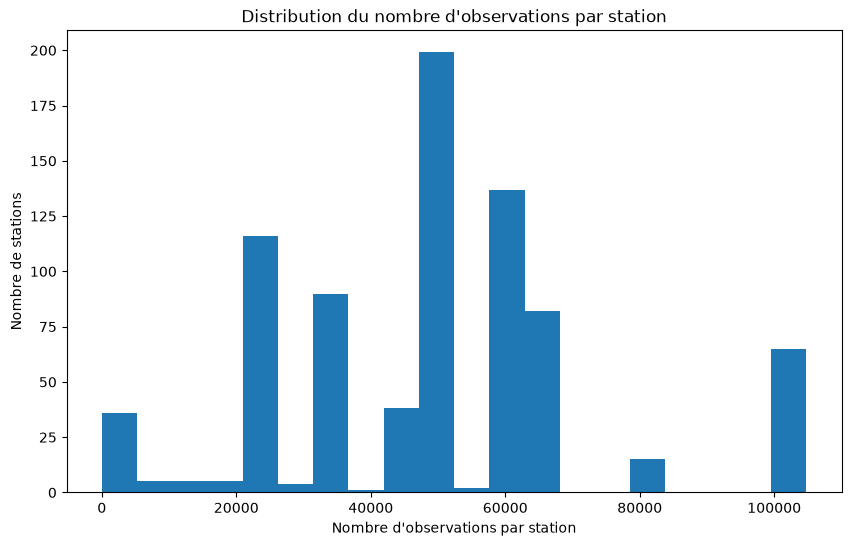

In [7]:
nb_obs = (
    history_toulouse_train
    .groupby(level="station")
    .count()
)

print(nb_obs)

vect_nb_obs = nb_obs["bikes"]

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.hist(vect_nb_obs, bins=20)

plt.xlabel("Nombre d'observations par station")
plt.ylabel("Nombre de stations")
plt.title("Distribution du nombre d'observations par station")

plt.show()

<div style="font-size: 1em; font-weight: bold; margin-top: 0.67em; margin-bottom: 0.67em;">
(d) Dates de début et de fin des mesures par stations et représentation graphique de leur dispersion
</div>

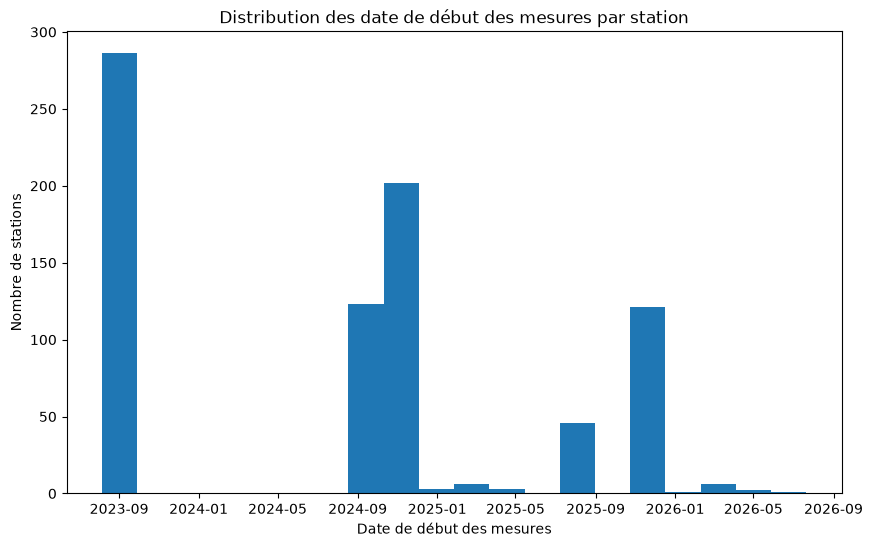

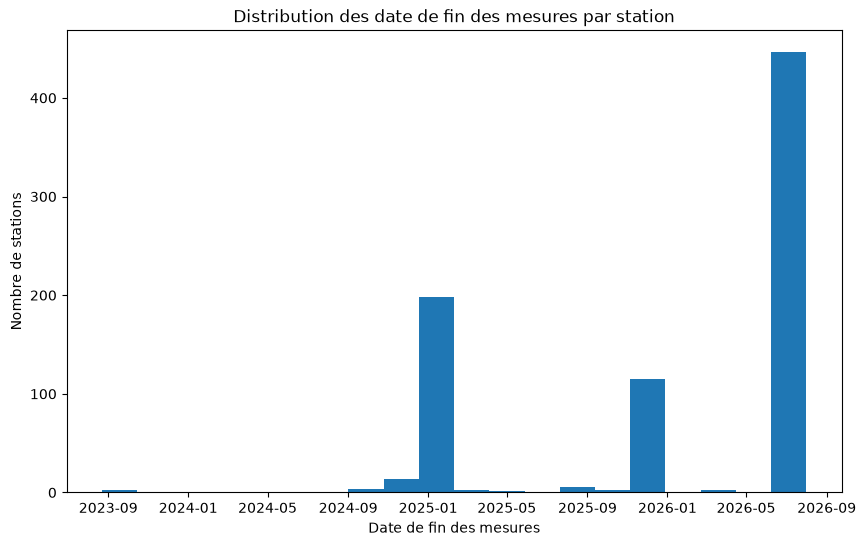

In [8]:
heure_debut = history_toulouse_train.groupby(level = "station").head(1).index.get_level_values("commit_at")
heure_fin = history_toulouse_train.groupby(level = "station").tail(1).index.get_level_values("commit_at")

plt.figure(figsize=(10, 6))

plt.hist(heure_debut, bins=20)

plt.xlabel("Date de début des mesures")
plt.ylabel("Nombre de stations")
plt.title("Distribution des date de début des mesures par station")

plt.show()

plt.figure(figsize=(10, 6))

plt.hist(heure_fin, bins=20)

plt.xlabel("Date de fin des mesures")
plt.ylabel("Nombre de stations")
plt.title("Distribution des date de fin des mesures par station")

plt.show()

<div style="font-size: 1em; font-weight: bold; margin-top: 0.67em; margin-bottom: 0.67em;">
(e) Statistique de base par station
</div>

<Axes: >

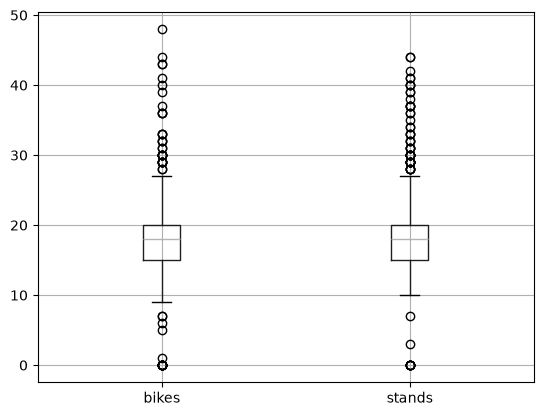

In [9]:
min_velos = (
    history_toulouse_train
    .groupby(level="station")
    .min()
    .copy()
)
mean_velos = (
    history_toulouse_train
    .groupby(level="station")
    .mean()
    .copy()
)
ecart_type_velos = (
    history_toulouse_train
    .groupby(level="station")
    .std()
    .copy()
)
premier_quartile_velos = (
    history_toulouse_train
    .groupby(level="station")
    .quantile(0.25)
    .copy()
)
mediane_velos = (
    history_toulouse_train
    .groupby(level="station")
    .quantile(0.5)
    .copy()
)
dernier_quartile_velos = (
    history_toulouse_train
    .groupby(level="station")
    .quantile(0.75)
    .copy()
)

max_velos.boxplot()

<Axes: >

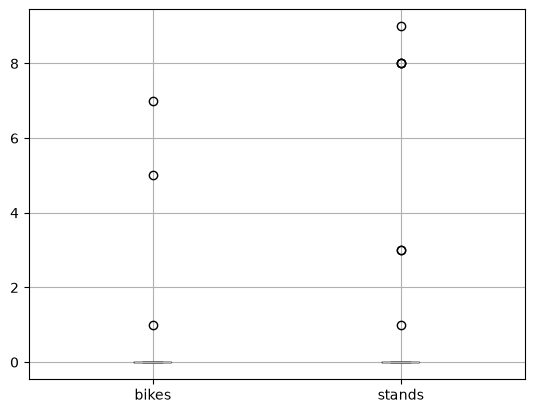

In [10]:
min_velos.boxplot()

<Axes: >

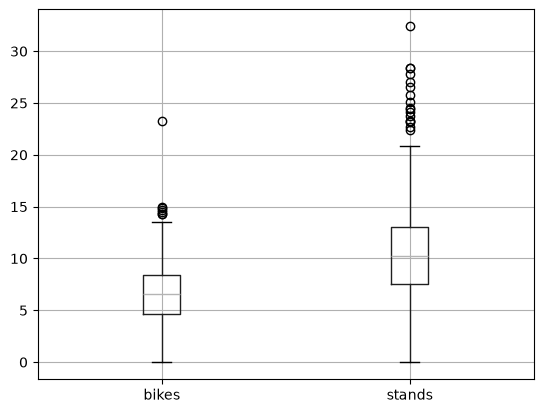

In [11]:
mean_velos.boxplot()

<Axes: >

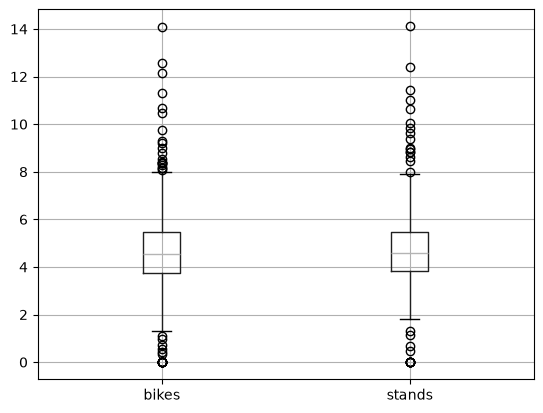

In [12]:
ecart_type_velos.boxplot()

<Axes: >

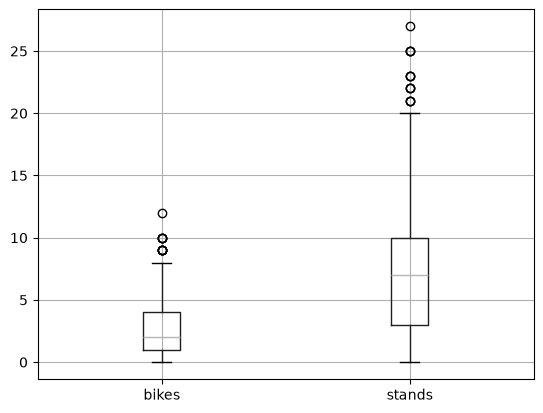

In [13]:
premier_quartile_velos.boxplot()

<Axes: >

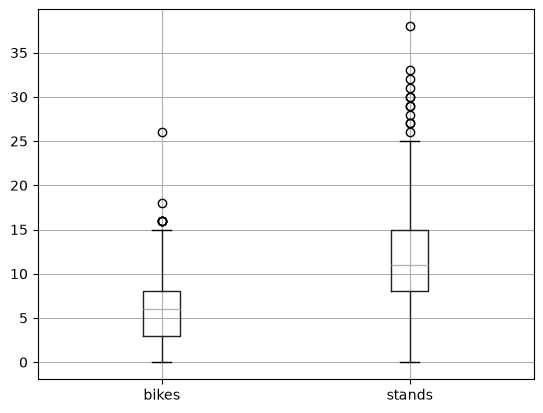

In [14]:
mediane_velos.boxplot()

<Axes: >

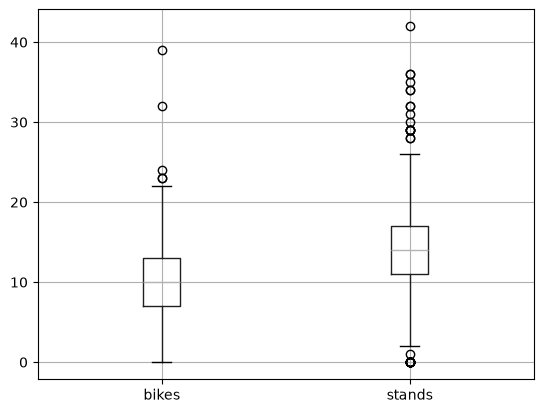

In [15]:
dernier_quartile_velos.boxplot()

<div style="font-size: 1em; font-weight: bold; margin-top: 0.67em; margin-bottom: 0.67em;">
(f) Courbe moyenne journalière de remplissage d'une station (toutes les 15 minutes), et de l'ensemble des stations / calculer également la courbe médiane, 1er-quartile, 3-ème quartile
</div>
Courbe de la moyenne journalière de remplissage d'une station

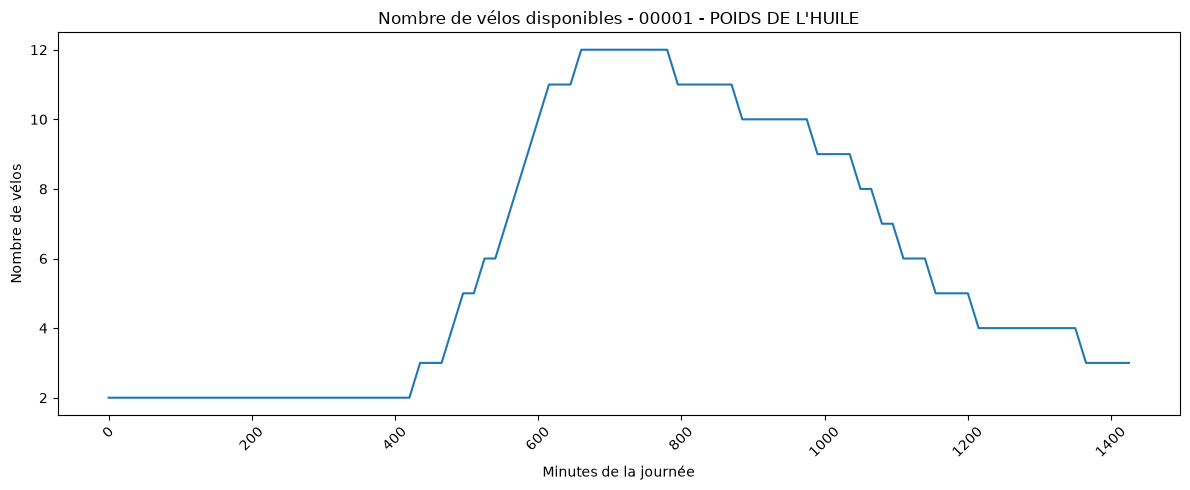

In [16]:
# On convertit les indexe en colonnes classiques
train = history_toulouse_train.reset_index()

#On convertit les chaines de caractère en format date en on extrait les heures et les minutes
train["heure"] = train["commit_at"].dt.hour
train["minutes"] = train["commit_at"].dt.minute

# Moyenne par quart d'heure de chaque station
moyenne_station_heure = train.groupby(["station", "heure", "minutes"])["bikes"].mean().round().astype(int)

# Nom d'une station que l'on souhaite étudier
station = "00001 - POIDS DE L'HUILE"

# Sélection de toutes les observations de cette station
donnees_station = moyenne_station_heure.loc[station]
liste_minutes = [heure * 60 + minute for heure, minute in donnees_station.index]

plt.figure(figsize=(12, 5))

plt.plot(
    liste_minutes,   # les dates de mesure
    donnees_station.values   # le nombre de vélos
)

plt.xlabel("Minutes de la journée")
plt.ylabel("Nombre de vélos")
plt.title(f"Nombre de vélos disponibles - {station}")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Courbe de la moyenne journalière de remplissage de l'ensemble des stations

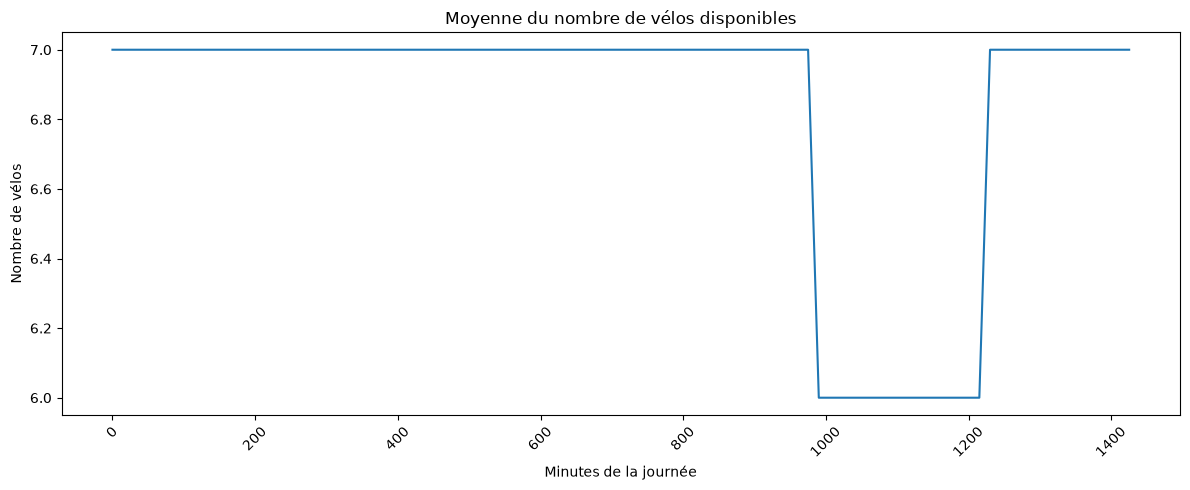

In [17]:
# Moyenne par quart d'heure de l'ensemble des stations
moyenne_station_heure = train.groupby(["heure", "minutes"])["bikes"].mean().round().astype(int)


# Sélection de toutes les observations de cette station
liste_minutes = [heure * 60 + minute for heure, minute in moyenne_station_heure.index]

plt.figure(figsize=(12, 5))

plt.plot(
    liste_minutes,   # les dates de mesure
    moyenne_station_heure.values   # le nombre de vélos
)

plt.xlabel("Minutes de la journée")
plt.ylabel("Nombre de vélos")
plt.title(f"Moyenne du nombre de vélos disponibles")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Courbe du premier quartile journalière de remplissage de l'ensemble des stations

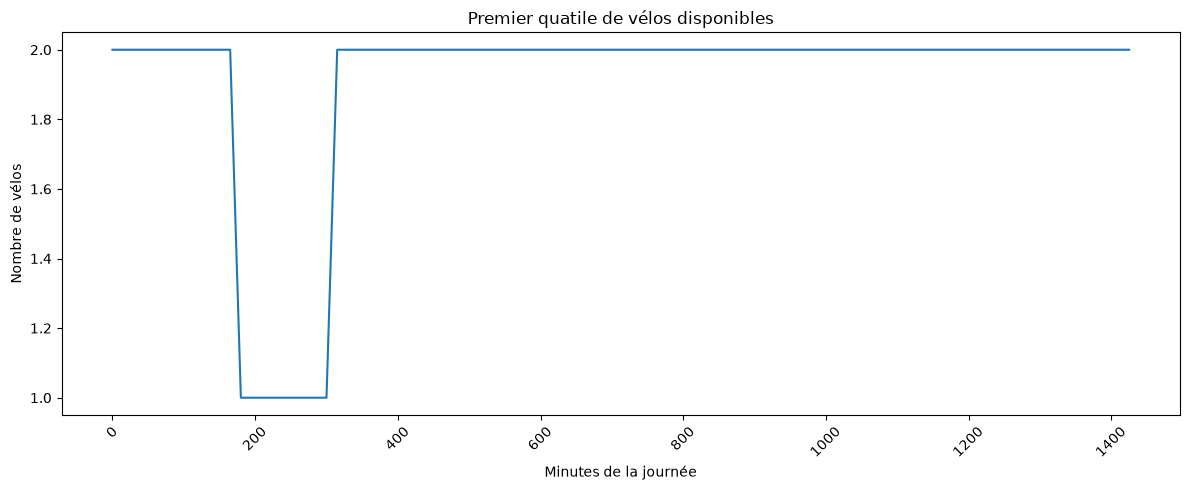

In [18]:
# Moyenne par quart d'heure de l'ensemble des stations
moyenne_station_heure = train.groupby(["heure", "minutes"])["bikes"].quantile(0.25).round().astype(int)


# Sélection de toutes les observations de cette station
liste_minutes = [heure * 60 + minute for heure, minute in moyenne_station_heure.index]

plt.figure(figsize=(12, 5))

plt.plot(
    liste_minutes,   # les dates de mesure
    moyenne_station_heure.values   # le nombre de vélos
)

plt.xlabel("Minutes de la journée")
plt.ylabel("Nombre de vélos")
plt.title(f"Premier quatile de vélos disponibles")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Courbe de la médiane journalière de remplissage de l'ensemble des stations

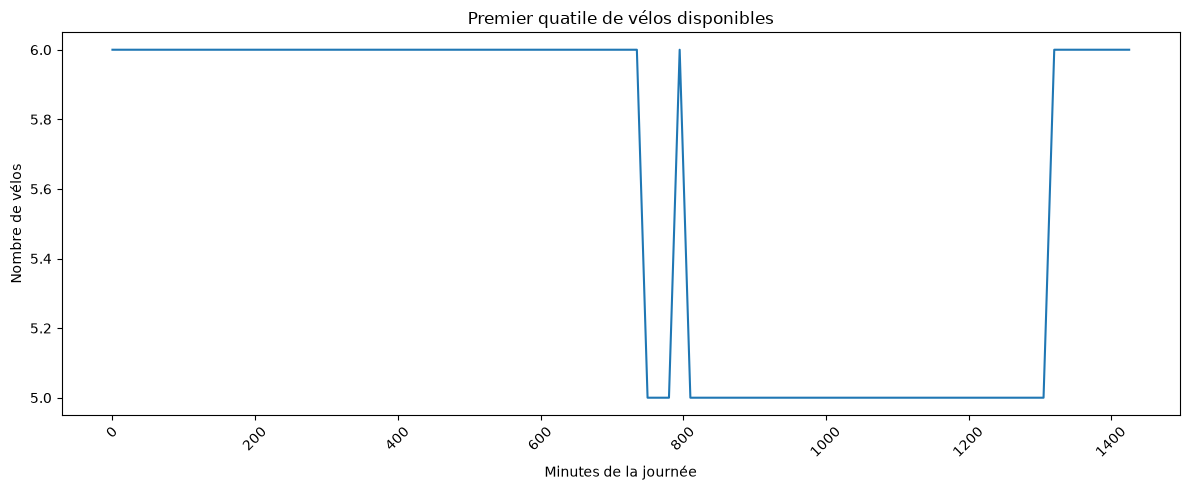

In [19]:
# Moyenne par quart d'heure de l'ensemble des stations
moyenne_station_heure = train.groupby(["heure", "minutes"])["bikes"].quantile(0.5).round().astype(int)


# Sélection de toutes les observations de cette station
liste_minutes = [heure * 60 + minute for heure, minute in moyenne_station_heure.index]

plt.figure(figsize=(12, 5))

plt.plot(
    liste_minutes,   # les dates de mesure
    moyenne_station_heure.values   # le nombre de vélos
)

plt.xlabel("Minutes de la journée")
plt.ylabel("Nombre de vélos")
plt.title(f"Premier quatile de vélos disponibles")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Courbe du toisième quartile journalière de remplissage de l'ensemble des stations

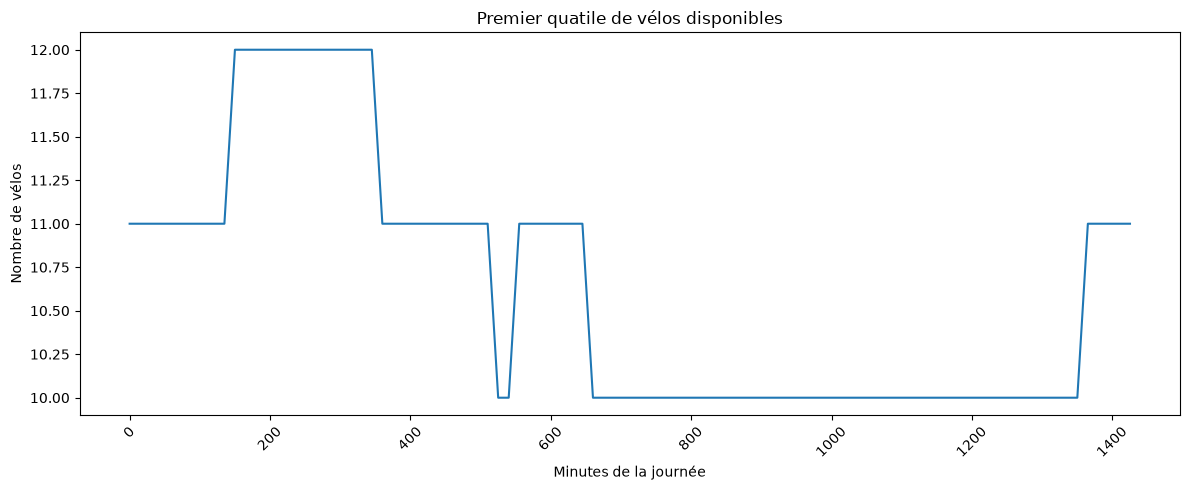

In [20]:
# Moyenne par quart d'heure de l'ensemble des stations
moyenne_station_heure = train.groupby(["heure", "minutes"])["bikes"].quantile(0.75).round().astype(int)


# Sélection de toutes les observations de cette station
liste_minutes = [heure * 60 + minute for heure, minute in moyenne_station_heure.index]

plt.figure(figsize=(12, 5))

plt.plot(
    liste_minutes,   # les dates de mesure
    moyenne_station_heure.values   # le nombre de vélos
)

plt.xlabel("Minutes de la journée")
plt.ylabel("Nombre de vélos")
plt.title(f"Premier quatile de vélos disponibles")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<div style="font-size: 1em; font-weight: bold; margin-top: 0.67em; margin-bottom: 0.67em;">
(g) Evolution temporelle de remplissage moyen de l'ensemble des stations et déduction des dynamiques urbaines de remplissage en fonction des heures de la journée et de la localisation des stations
</div>
On calcule le taux de remplissage de chaque station à tout instant

In [21]:
train["total"] = train["bikes"] + train["stands"]
train["occupation"] = train["bikes"] / train["total"].replace(0, 1)

Evolution temporelle du taux remplissage moyen de l'ensemble des stations : 5h00

In [22]:
rapport_station_heure = train.groupby(["station", "heure", "minutes"])["occupation"].mean()
matin_bikes = rapport_station_heure.loc[(slice(None), 5, 0)]

m = carte_coloree(matin_bikes, "Taux d'occupation", 0, 1)
m

12h

In [23]:
rapport_station_heure = train.groupby(["station", "heure", "minutes"])["occupation"].mean()
matin_bikes = rapport_station_heure.loc[(slice(None), 12, 0)]

m = carte_coloree(matin_bikes, "Taux d'occupation", 0, 1)
m

23h

In [24]:
rapport_station_heure = train.groupby(["station", "heure", "minutes"])["occupation"].mean()
matin_bikes = rapport_station_heure.loc[(slice(None), 23, 00)]

m = carte_coloree(matin_bikes, "Taux d'occupation", 0, 1)
m

On constate que à 5h du matin, quand tout le monde dors, les stations des zones résidentielles sont bien remplies tandis que les stations du centre-ville sont quasiment vides. <br>
A midi tout le monde travaille donc c'est l'inverse : les zones résidentielles sont quasiment vides tandis que le centre-ville est plein. <br>
Enfin à 23h le centre-ville commence à se vider tandis que les quartiers résidentiels se remplissent.

<div style="font-size: 2em; font-weight: bold; margin-top: 0.67em; margin-bottom: 0.67em;">
Méthodes de prévision basiques
</div>

Vous devez inclure ici une description des méthodes de bases que vous avez explorées, ainsi qu'une évaluation de leurs performances (cacul de l'erreur RMSE) sur un jeu de données de validation créé à partir de l'ensemble d'apprentissage.

Il est attendu :

- une proposition de 3 méthodes de prévision
- leur classement en terme de performances par calcul de l'erreur RMSE sur l'ensemble de validation
- leurs prévisions sur l'ensemble test à déposer sur Moodle

**Création d'un ensemble de validation**

Le principe de création d'un ensemble de validation est le suivant. Les données disponibles sont partagées en deux sous-ensembles disjoints :

- un ensemble d'apprentissage qui va servir à créer un modèle de prévision
- un ensemble de validation qui va servir à évaluer le modèle de prévision

Il s'agit d'un principe fondamental en apprentissage statistique qui consiste à construire une méthode d'estimation puis **la tester sur un jeu de données qui n'a pas servi à sa construction**.

Dans ce projet, pour créer l'ensemble de validation, on peut simplement retirer les 8 denières mesures dans chaque station de ``history_toulouse_train`` et conserver le reste des données pour l'apprentissage.

In [25]:
# Exemple de création d'un jeu de données d'apprentissage et un jeu de données de validation

# Création ensemble d'apprentissage
# Suppression des 8 dernières mesures de chaque station
rang_depuis_la_fin = (
    history_toulouse_train
    .groupby(level="station")
    .cumcount(ascending=False)
)
rang_depuis_la_fin

station                   commit_at          
00001 - POIDS DE L'HUILE  2023-08-05 12:15:00    104774
                          2023-08-05 12:30:00    104773
                          2023-08-05 12:45:00    104772
                          2023-08-05 13:00:00    104771
                          2023-08-05 13:15:00    104770
                                                  ...  
TEST BEE                  2026-02-12 15:00:00         4
                          2026-02-12 15:15:00         3
                          2026-02-12 15:30:00         2
                          2026-02-12 15:45:00         1
                          2026-02-12 16:00:00         0
Length: 40012622, dtype: int64

In [26]:
history_toulouse_apprentissage = history_toulouse_train[
    rang_depuis_la_fin >= 8
].copy()
history_toulouse_apprentissage

bikes  stands
station                  commit_at                         
00001 - POIDS DE L'HUILE 2023-08-05 12:15:00     10       9
                         2023-08-05 12:30:00     10       9
                         2023-08-05 12:45:00     10       9
                         2023-08-05 13:00:00     11       8
                         2023-08-05 13:15:00     11       8
...                                             ...     ...
TEST BEE                 2026-02-12 13:00:00      0       3
                         2026-02-12 13:15:00      0       3
                         2026-02-12 13:30:00      0       3
                         2026-02-12 13:45:00      0       3
                         2026-02-12 14:00:00      0       3

[40006230 rows x 2 columns]

In [27]:
# Récupèration de la dernière date de mesure pour chaque station
# des données d'apprentissage
last_apprentissage = (
    history_toulouse_apprentissage
    .groupby(level="station")
    .tail(1)
    .copy()
)

last_apprentissage

,,bikes,stands
station,commit_at,,
00001 - POIDS DE L'HUILE,2026-07-31 19:45:00,6,10
00002 - LAFAYETTE,2026-07-31 21:45:00,5,13
00003 - ALSACE - LORRAINE - POMME,2025-11-10 09:45:00,7,11
00003 - ALSACE-LORRAINE - POMME,2026-07-31 19:45:00,15,1
00003 - POMME,2025-01-05 03:45:00,17,0
...,...,...,...
MONT LOUIS –AV. DE TOULOUSE,2026-03-23 18:15:00,10,5
NARBONNE - CLOTASSES,2025-08-22 17:15:00,0,16
PASTEUR - LAVOISIER,2025-08-05 08:15:00,0,0


In [28]:
# Creation de l'ensemble de validation
# On récupère les 9 dernières mesures :
# - la 1ère = dernière mesure dans l'ensemble d'apprentissage
# - les 8 suivantes = valeurs à prédire
last_9 = (
    history_toulouse_train
    .groupby(level="station")
    .tail(9)
    .copy()
)
last_9

bikes  stands
station                  commit_at                         
00001 - POIDS DE L'HUILE 2026-07-31 19:45:00      6      10
                         2026-07-31 20:00:00      1      15
                         2026-07-31 20:15:00      1      15
                         2026-07-31 20:30:00      1      15
                         2026-07-31 20:45:00      1      15
...                                             ...     ...
TEST BEE                 2026-02-12 15:00:00      0       3
                         2026-02-12 15:15:00      0       3
                         2026-02-12 15:30:00      0       3
                         2026-02-12 15:45:00      0       3
                         2026-02-12 16:00:00      0       3

[7189 rows x 2 columns]

In [29]:
# On remet l'index sous forme de colonnes
last_9 = last_9.reset_index()
last_9

,station,commit_at,bikes,stands
0,00001 - POIDS DE L'HUILE,2026-07-31 19:45:00,6,10
1,00001 - POIDS DE L'HUILE,2026-07-31 20:00:00,1,15
2,00001 - POIDS DE L'HUILE,2026-07-31 20:15:00,1,15
3,00001 - POIDS DE L'HUILE,2026-07-31 20:30:00,1,15
4,00001 - POIDS DE L'HUILE,2026-07-31 20:45:00,1,15
...,...,...,...,...
7184,TEST BEE,2026-02-12 15:00:00,0,3
7185,TEST BEE,2026-02-12 15:15:00,0,3
7186,TEST BEE,2026-02-12 15:30:00,0,3
7187,TEST BEE,2026-02-12 15:45:00,0,3


In [31]:
last_9["horizon"] = (
    last_9.groupby("station").cumcount()
)
last_9

,station,commit_at,bikes,stands,horizon
0,00001 - POIDS DE L'HUILE,2026-07-31 19:45:00,6,10,0
1,00001 - POIDS DE L'HUILE,2026-07-31 20:00:00,1,15,1
2,00001 - POIDS DE L'HUILE,2026-07-31 20:15:00,1,15,2
3,00001 - POIDS DE L'HUILE,2026-07-31 20:30:00,1,15,3
4,00001 - POIDS DE L'HUILE,2026-07-31 20:45:00,1,15,4
...,...,...,...,...,...
7184,TEST BEE,2026-02-12 15:00:00,0,3,4
7185,TEST BEE,2026-02-12 15:15:00,0,3,5
7186,TEST BEE,2026-02-12 15:30:00,0,3,6
7187,TEST BEE,2026-02-12 15:45:00,0,3,7


In [32]:
# Recherche de valeurs manquantes
missing = last_9.loc[
    last_9[['bikes', 'stands']].isna().any(axis=1),
    ['station', 'commit_at', 'bikes', 'stands']
]

print(missing)

Empty DataFrame
Columns: [station, commit_at, bikes, stands]
Index: []


In [33]:
# On crée une ligne par station et on récupère les 8 valeurs futures
history_toulouse_validation = (
    last_9
    .pivot(
        index="station",
        columns="horizon",
        values="bikes"
    )
    .drop(columns=0)
    .rename(columns={
        1: "bikes_+15min",
        2: "bikes_+30min",
        3: "bikes_+45min",
        4: "bikes_+60min",
        5: "bikes_+75min",
        6: "bikes_+90min",
        7: "bikes_+105min",
        8: "bikes_+120min"
    })
)

# Récupérer la date de la dernière mesure de l'ensemble d'apprentissage par station
cutoff_times = (
    last_9[last_9["horizon"] == 0]
    .set_index("station")["commit_at"]
)

# Ajouter commit_at
history_toulouse_validation["commit_at"] = cutoff_times

# Mettre station + commit_at en MultiIndex
history_toulouse_validation = (
    history_toulouse_validation
    .reset_index()
    .set_index(["station", "commit_at"])
    .sort_index()
)

history_toulouse_validation

,horizon,bikes_+15min,bikes_+30min,bikes_+45min,bikes_+60min,bikes_+75min,bikes_+90min,bikes_+105min,bikes_+120min
station,commit_at,,,,,,,,
00001 - POIDS DE L'HUILE,2026-07-31 19:45:00,1.0,1.0,1.0,1.0,1.0,1.0,9.0,9.0
00002 - LAFAYETTE,2026-07-31 21:45:00,5.0,5.0,5.0,9.0,9.0,9.0,9.0,9.0
00003 - ALSACE - LORRAINE - POMME,2025-11-10 09:45:00,9.0,12.0,15.0,16.0,17.0,17.0,17.0,18.0
00003 - ALSACE-LORRAINE - POMME,2026-07-31 19:45:00,0.0,0.0,0.0,0.0,0.0,0.0,12.0,12.0
00003 - POMME,2025-01-05 03:45:00,17.0,17.0,17.0,17.0,17.0,17.0,17.0,17.0
...,...,...,...,...,...,...,...,...,...
NARBONNE - CLOTASSES,2025-08-22 17:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
PASTEUR - LAVOISIER,2025-08-05 08:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
PLACE GEORGES BRASSENS,2025-08-05 09:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN


**Exemple d'évaluation d'une méthode de prévision**

On donne ci-dessous l'exemple du calcul de l'erreur RMSE sur l'ensemble de validation d'une méthode de base à partir de la moyenne des vélos par station sur l'ensemble d'apprentissage

In [34]:
# Creation des données à prédire
history_toulouse_basique = history_toulouse_validation.copy()

# Methode de base
mean_bikes_station = (
    history_toulouse_apprentissage
    .groupby(level="station")["bikes"]
    .mean()
    .round()
)

target_columns = [
    "bikes_+15min",
    "bikes_+30min",
    "bikes_+45min",
    "bikes_+60min",
    "bikes_+75min",
    "bikes_+90min",
    "bikes_+105min",
    "bikes_+120min"
]

# Station correspondant à chaque ligne de l'ensemble de validation
stations_a_predire = history_toulouse_basique.index.get_level_values("station")

# Moyenne de chaque station à prédire
predictions = mean_bikes_station.reindex(stations_a_predire)

# Remplissage des 8 horizons avec la même moyenne
history_toulouse_basique.loc[:, target_columns] = (
    predictions.to_numpy()[:, None]
)

In [35]:
history_toulouse_basique

,horizon,bikes_+15min,bikes_+30min,bikes_+45min,bikes_+60min,bikes_+75min,bikes_+90min,bikes_+105min,bikes_+120min
station,commit_at,,,,,,,,
00001 - POIDS DE L'HUILE,2026-07-31 19:45:00,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0
00002 - LAFAYETTE,2026-07-31 21:45:00,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0
00003 - ALSACE - LORRAINE - POMME,2025-11-10 09:45:00,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0
00003 - ALSACE-LORRAINE - POMME,2026-07-31 19:45:00,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0
00003 - POMME,2025-01-05 03:45:00,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0
...,...,...,...,...,...,...,...,...,...
NARBONNE - CLOTASSES,2025-08-22 17:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
PASTEUR - LAVOISIER,2025-08-05 08:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
PLACE GEORGES BRASSENS,2025-08-05 09:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [36]:
history_toulouse_validation

,horizon,bikes_+15min,bikes_+30min,bikes_+45min,bikes_+60min,bikes_+75min,bikes_+90min,bikes_+105min,bikes_+120min
station,commit_at,,,,,,,,
00001 - POIDS DE L'HUILE,2026-07-31 19:45:00,1.0,1.0,1.0,1.0,1.0,1.0,9.0,9.0
00002 - LAFAYETTE,2026-07-31 21:45:00,5.0,5.0,5.0,9.0,9.0,9.0,9.0,9.0
00003 - ALSACE - LORRAINE - POMME,2025-11-10 09:45:00,9.0,12.0,15.0,16.0,17.0,17.0,17.0,18.0
00003 - ALSACE-LORRAINE - POMME,2026-07-31 19:45:00,0.0,0.0,0.0,0.0,0.0,0.0,12.0,12.0
00003 - POMME,2025-01-05 03:45:00,17.0,17.0,17.0,17.0,17.0,17.0,17.0,17.0
...,...,...,...,...,...,...,...,...,...
NARBONNE - CLOTASSES,2025-08-22 17:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
PASTEUR - LAVOISIER,2025-08-05 08:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
PLACE GEORGES BRASSENS,2025-08-05 09:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN


In [37]:
# Recherche de valeurs manquantes
print("Nombre de valeurs manquantes :", predictions.isna().sum())
print("Valeurs manquantes :", predictions[predictions.isna()])

Nombre de valeurs manquantes : 3
Valeurs manquantes : station
00004 - GAMBETTA - SAINTE-URSULE   NaN
9006 - MAROTS - TINEE              NaN
PLACE GEORGES BRASSENS             NaN
Name: bikes, dtype: float64


In [38]:
# Gestion des valeurs manquantes
stations_problematiques = stations_a_predire[predictions.isna()]
print(stations_problematiques)

Index(['00004 - GAMBETTA - SAINTE-URSULE', '9006 - MAROTS - TINEE',
       'PLACE GEORGES BRASSENS'],
      dtype='str', name='station')


In [39]:
# Nombre d'observations par station
nb_obs = (
    history_toulouse_train
    .groupby(level="station")
    .count()
)
nb_obs

,bikes,stands
station,,
00001 - POIDS DE L'HUILE,104775,104775
00002 - LAFAYETTE,104783,104783
00003 - ALSACE - LORRAINE - POMME,36008,36008
00003 - ALSACE-LORRAINE - POMME,25278,25278
00003 - POMME,49799,49799
...,...,...
NARBONNE - CLOTASSES,885,885
PASTEUR - LAVOISIER,98,98
PLACE GEORGES BRASSENS,8,8


In [40]:
import numpy as np
np.min(nb_obs)

np.int64(3)

In [41]:
print(nb_obs.loc[stations_problematiques])

                                  bikes  stands
station                                        
00004 - GAMBETTA - SAINTE-URSULE      5       5
9006 - MAROTS - TINEE                 3       3
PLACE GEORGES BRASSENS                8       8


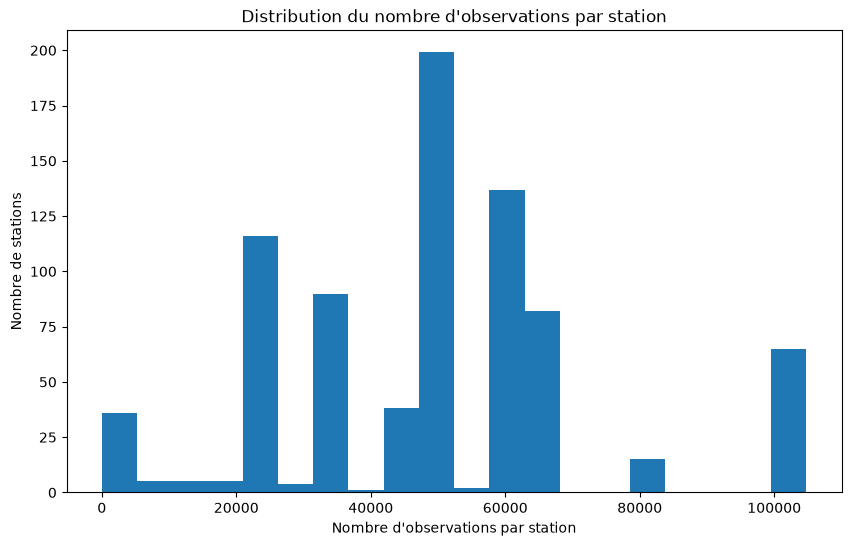

In [42]:
vect_nb_obs = nb_obs["bikes"]

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.hist(vect_nb_obs, bins=20)

plt.xlabel("Nombre d'observations par station")
plt.ylabel("Nombre de stations")
plt.title("Distribution du nombre d'observations par station")

plt.show()

In [43]:
# Stations sans valeurs manquantes
stations_sans_NaN = stations_a_predire[predictions.notna()]
print(stations_sans_NaN)

Index(['00001 - POIDS DE L'HUILE', '00002 - LAFAYETTE',
       '00003 - ALSACE - LORRAINE - POMME', '00003 - ALSACE-LORRAINE - POMME',
       '00003 - POMME', '00004 - GAMBETTA - SAINTE - URSULE',
       '00004 - GAMBETTA - STE-URSULE', '00004 - SAINTE-URSULE',
       '00005 - LEDUC', '00005 - MARENGO - LEDUC',
       ...
       '1032 -  BORNE CGB ATELIER 2', '9001 - COLOMIERS MAIRIE',
       '9005 - ALLENDE - ADOUR', 'BRUNAUD - CEAT', 'CAYRAS –CATALA',
       'MONT LOUIS –AV. DE TOULOUSE', 'NARBONNE - CLOTASSES',
       'PASTEUR - LAVOISIER', 'SERVANTY AIRBUS TRAMWAY', 'TEST BEE'],
      dtype='str', name='station', length=797)


In [44]:
import numpy as np

history_toulouse_validation.values

array([[ 1.,  1.,  1., ...,  1.,  9.,  9.],
       [ 5.,  5.,  5., ...,  9.,  9.,  9.],
       [ 9., 12., 15., ..., 17., 17., 18.],
       ...,
       [ 0.,  0.,  0., ...,  0.,  0., nan],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.]], shape=(800, 8))

In [45]:
# Calcul de l'erreur RMSE sur l'ensemble de validation
rmse = np.sqrt((
    (history_toulouse_basique.values- history_toulouse_validation.values)**2
).mean())
print(f'RMSE',rmse)

RMSE nan


In [46]:
# Calcul de l'erreur RMSE sur l'ensemble de validation
rmse = np.sqrt((
    (history_toulouse_basique.loc[stations_sans_NaN].values- history_toulouse_validation.loc[stations_sans_NaN].values)**2
).mean())
print(f'RMSE',rmse)

RMSE 5.218755987081368


<div style="font-size: 2em; font-weight: bold; margin-top: 0.67em; margin-bottom: 0.67em;">
Fichiers fournis : <br>
- MoyenneQuartHeure <br>
- <br>
-
</div>

<div style="font-size: 2em; font-weight: bold; margin-top: 0.67em; margin-bottom: 0.67em;">
Prévision par apprentissage statistique
</div>

A venir...